<a href="https://colab.research.google.com/github/pulindu-seniya-silva/ASAS_FDM/blob/cat_boost-uvindu/catBoost_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pre-processing

Importing relevent libraries

Importing dataset

Keeping save copies of the dataset

In [2]:
import os, re, json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from scipy import sparse
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, recall_score, balanced_accuracy_score
)

CSV_PATH = "/content/Road_Accident_Data_s_15.csv"   # drag and drop dataset directly to the files in colab and keep this as it is
OUTDIR   = "artifacts"
TEST_SIZE = 0.20
RANDOM_STATE = 42

os.makedirs(OUTDIR, exist_ok=True)

# load and keep a safe raw copy
df_in  = pd.read_csv(CSV_PATH)
df_raw = df_in.copy(deep=True)   # audit/rollback
df     = df_in.copy(deep=True)   # working copy

print("Loaded:", df.shape)
print("Dataset:")
df.head(5)

def evaluate(y_true, y_pred, title=""):
    print(f"\n=== {title} ===")
    print("Macro F1:       ", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("Recall (macro): ", round(recall_score(y_true, y_pred, average="macro"), 4))
    print("Balanced Acc:   ", round(balanced_accuracy_score(y_true, y_pred), 4))
    print("\nClassification report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    cm_norm = (cm.T / cm.sum(axis=1, where=cm.sum(axis=1)!=0)).T  # safe normalize
    print("Confusion matrix (row-normalized):\n", np.round(cm_norm, 3))

Loaded: (27520, 21)
Dataset:


<Axes: xlabel='Accident_Severity'>

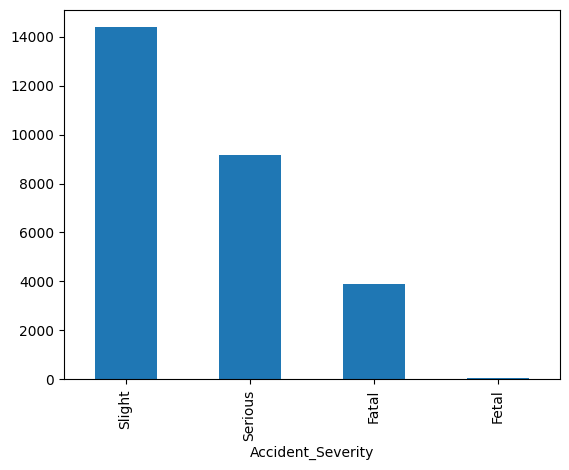

In [3]:
#plot severity classes in a bar char
df['Accident_Severity'].value_counts().plot(kind='bar')

drop purely irrelevant columns early

In [4]:
early_drop = [c for c in [
    "Accident_Index",
] if c in df.columns]

df = df.drop(columns=early_drop, errors="ignore")
print("After early drop:", df.shape)
print("Dropped:", early_drop)


After early drop: (27520, 20)
Dropped: ['Accident_Index']


Implimenting string hygene utils

In [5]:
def strip_collapse(s):
    if pd.isna(s): return s
    return re.sub(r"\s+", " ", str(s).strip())

def map_values(series, mapping):
    return series.replace(mapping)

def bucket_rare(series, min_count=100, other_label="Other"):
    vc = series.value_counts(dropna=False)
    rare = vc[vc < min_count].index
    return series.where(~series.isin(rare), other_label)

# trim whitespace on all object columns to avoid duplicate labels
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(strip_collapse)


**Basic cleaning**

- Fix tatget label typos and remove missing values

In [6]:
if "Accident_Severity" in df.columns:
    df["Accident_Severity"] = df["Accident_Severity"].astype("object")
    # from your counts: "Fetal" is a typo
    df["Accident_Severity"] = map_values(df["Accident_Severity"],
                                         {"Fetal": "Fatal", "fetal": "Fatal"})
    before = df.shape[0]
    df = df[~df["Accident_Severity"].isna()].copy()
    print("Dropped rows with missing Accident_Severity:", before - df.shape[0])


Dropped rows with missing Accident_Severity: 0


In [7]:
df["Accident_Severity"] = df["Accident_Severity"].replace({
    "Fatal": "Severe",
    "Serious": "Severe",
    "Slight": "Slight"
})


<Axes: xlabel='Accident_Severity'>

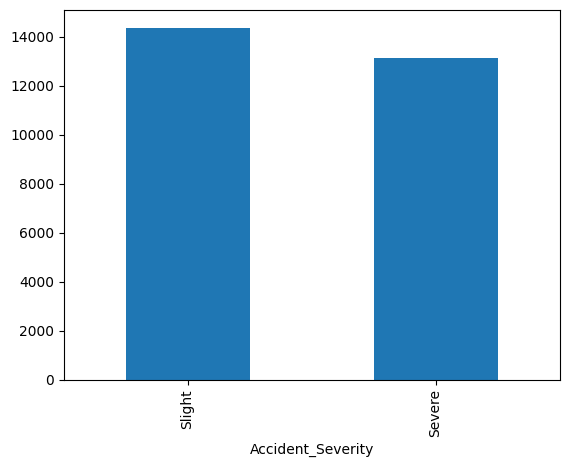

In [8]:
df['Accident_Severity'].value_counts().plot(kind='bar')

- parse "accident_date" and recompute "Day_of_Week"

In [9]:
if "Accident Date" in df.columns:
    df["Accident Date"] = pd.to_datetime(df["Accident Date"], errors="coerce", dayfirst=True)
    print("Unparseable dates:", df["Accident Date"].isna().sum())

    # recompute Day_of_Week from parsed date (consistent + fixes 1 NaN)
    df["Day_of_Week"] = df["Accident Date"].dt.day_name()


Unparseable dates: 16686


- normalize "Time" to HH:MM and flag invalid

In [10]:
if "Time" in df.columns:
    def normalize_time(x):
        if pd.isna(x): return np.nan
        s = str(x).strip()
        m = re.match(r"^(\d{1,2}):(\d{2})$", s)
        if not m: return np.nan
        hh, mm = int(m.group(1)), int(m.group(2))
        if 0 <= hh <= 23 and 0 <= mm <= 59:
            return f"{hh:02d}:{mm:02d}"
        return np.nan

    df["Time"] = df["Time"].apply(normalize_time)
    print("Invalid/NaN times:", df["Time"].isna().sum())


Invalid/NaN times: 2


- Harmonize "unknown" values and shorten long labels

In [11]:
# unify explicit "Unknown" labels
if "Junction_Control" in df.columns:
    df["Junction_Control"] = map_values(df["Junction_Control"],
                                        {"Data missing or out of range": "Unknown"})

if "Junction_Detail" in df.columns:
    df["Junction_Detail"] = map_values(df["Junction_Detail"],
                                       {"Not at junction or within 20 metres": "Not at junction"})

# fill NaN -> "Unknown" for key categoricals
for col in ["Light_Conditions","Weather_Conditions","Road_Surface_Conditions",
            "Road_Type","Junction_Control","Junction_Detail",
            "Urban_or_Rural_Area"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Compact some verbose labels (optional but cleaner for OHE and plots)
if "Light_Conditions" in df.columns:
    df["Light_Conditions"] = map_values(df["Light_Conditions"], {
        "Darkness - lights lit": "Dark_lit",
        "Darkness - lights unlit": "Dark_unlit",
        "Darkness - no lighting": "Dark_none",
        "Darkness - lighting unknown": "Dark_unknown",
    })

if "Weather_Conditions" in df.columns:
    df["Weather_Conditions"] = map_values(df["Weather_Conditions"], {
        "Fine + high winds": "Fine_high_winds",
        "Raining + high winds": "Rain_high_winds",
        "Raining no high winds": "Rain_no_high",
        "Snowing + high winds": "Snow_high_winds",
        "Snowing no high winds": "Snow_no_high",
        "Fog or mist": "Fog_mist",
        "Fine no high winds": "Fine_no_high",
    })

if "Road_Surface_Conditions" in df.columns:
    df["Road_Surface_Conditions"] = map_values(df["Road_Surface_Conditions"],
                                               {"Flood over 3cm. deep": "Flood_3cm_plus"})


In [12]:
df.head(5)

,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,2021-02-03,Wednesday,Give way or uncontrolled,T or staggered junction,Slight,51.559306,Daylight,Windsor and Maidenhead,NaN,-0.731105,1,2,Thames Valley,Wet or damp,Single carriageway,30,14:05,Urban,Other,Car
1,2021-07-03,Saturday,Give way or uncontrolled,T or staggered junction,Slight,51.532534,Daylight,Westminster,NaN,-0.174021,1,2,Metropolitan Police,Dry,Single carriageway,30,07:48,Urban,Fine_no_high,Car
2,NaT,NaN,Give way or uncontrolled,T or staggered junction,Severe,53.051271,Dark_lit,Amber Valley,NaN,-1.410837,3,1,Derbyshire,Wet or damp,Single carriageway,30,20:54,Urban,Rain_no_high,Goods 7.5 tonnes mgw and over
3,NaT,NaN,Not at junction or within 20 metres,Not at junction,Severe,51.860546,Daylight,Colchester,NaN,0.868276,1,1,Essex,Dry,Single carriageway,50,19:27,Rural,Fine_no_high,Car
4,NaT,NaN,Auto traffic signal,Roundabout,Slight,51.515247,Daylight,Newham,NaN,0.008765,1,1,Metropolitan Police,Dry,Roundabout,30,08:15,Urban,Fine_no_high,Car


**Feature engineering**

In [13]:
# Time_of_Day from Time
if "Time" in df.columns:
    def time_bucket(t):
        if pd.isna(t): return "Unknown"
        hh = int(t.split(":")[0])
        if 5 <= hh < 11:  return "Morning"
        if 11 <= hh < 16: return "Afternoon"
        if 16 <= hh < 20: return "Evening"
        return "Night"
    df["Time_of_Day"] = df["Time"].apply(time_bucket)

# Month / Season / Day_name from Accident Date
if "Accident Date" in df.columns:
    df["Month"] = df["Accident Date"].dt.month
    def season(m):
        if m in [12,1,2]:  return "Winter"
        if m in [3,4,5]:   return "Spring"
        if m in [6,7,8]:   return "Summer"
        if m in [9,10,11]: return "Autumn"
        return "Unknown"
    df["Season"]   = df["Month"].apply(season)
    df["Day_name"] = df["Accident Date"].dt.day_name()

# High speed flag
if "Speed_limit" in df.columns:
    df["High_Speed"] = (pd.to_numeric(df["Speed_limit"], errors="coerce") >= 60).astype(int)


In [14]:
df.head()

,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,...,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Time_of_Day,Month,Season,Day_name,High_Speed
0,2021-02-03,Wednesday,Give way or uncontrolled,T or staggered junction,Slight,51.559306,Daylight,Windsor and Maidenhead,NaN,-0.731105,...,30,14:05,Urban,Other,Car,Afternoon,2.0,Winter,Wednesday,0
1,2021-07-03,Saturday,Give way or uncontrolled,T or staggered junction,Slight,51.532534,Daylight,Westminster,NaN,-0.174021,...,30,07:48,Urban,Fine_no_high,Car,Morning,7.0,Summer,Saturday,0
2,NaT,NaN,Give way or uncontrolled,T or staggered junction,Severe,53.051271,Dark_lit,Amber Valley,NaN,-1.410837,...,30,20:54,Urban,Rain_no_high,Goods 7.5 tonnes mgw and over,Night,NaN,Unknown,NaN,0
3,NaT,NaN,Not at junction or within 20 metres,Not at junction,Severe,51.860546,Daylight,Colchester,NaN,0.868276,...,50,19:27,Rural,Fine_no_high,Car,Evening,NaN,Unknown,NaN,0
4,NaT,NaN,Auto traffic signal,Roundabout,Slight,51.515247,Daylight,Newham,NaN,0.008765,...,30,08:15,Urban,Fine_no_high,Car,Morning,NaN,Unknown,NaN,0


**Enforce numeric dtypes and quick sanity report**

In [15]:
for c in ["Speed_limit","Number_of_Vehicles","Number_of_Casualties","Month"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("\n=== Post-cleaning snapshot ===")
cols_to_peek = ["Accident_Severity","Day_of_Week","Light_Conditions","Weather_Conditions",
                "Road_Surface_Conditions","Road_Type","Junction_Control","Junction_Detail",
                "Urban_or_Rural_Area"]
for col in cols_to_peek:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique")
        print(df[col].value_counts(dropna=False).head(5).to_dict(), "\n")



=== Post-cleaning snapshot ===
Accident_Severity: 2 unique
{'Slight': 14382, 'Severe': 13138} 

Day_of_Week: 7 unique
{nan: 16686, 'Saturday': 1750, 'Friday': 1653, 'Thursday': 1601, 'Wednesday': 1574} 

Light_Conditions: 5 unique
{'Daylight': 19524, 'Dark_lit': 5634, 'Dark_none': 2016, 'Dark_unknown': 243, 'Dark_unlit': 103} 

Weather_Conditions: 8 unique
{'Fine_no_high': 22119, 'Rain_no_high': 3222, 'Other': 760, 'Snow_no_high': 396, 'Fog_mist': 392} 

Road_Surface_Conditions: 5 unique
{'Dry': 18838, 'Wet or damp': 7244, 'Frost or ice': 997, 'Snow': 396, 'Flood_3cm_plus': 45} 

Road_Type: 5 unique
{'Single carriageway': 20954, 'Dual carriageway': 4185, 'Roundabout': 1492, 'One way street': 547, 'Slip road': 342} 

Junction_Control: 7 unique
{'Give way or uncontrolled': 12373, 'Unknown': 9877, 'Auto traffic signal': 2623, 'Not at junction or within 20 metres': 2476, 'Stop sign': 126} 

Junction_Detail: 9 unique
{'Not at junction': 12322, 'T or staggered junction': 8183, 'Crossroads':

**Definiing input(x) and target(y) features**

In [16]:
assert "Accident_Severity" in df.columns
y = df["Accident_Severity"].astype("category")

candidate_X = [
    "Day_name","Time_of_Day","Month","Season",
    "Weather_Conditions","Light_Conditions","Road_Surface_Conditions",
    "Road_Type","Junction_Detail","Junction_Control",
    "Urban_or_Rural_Area","Speed_limit","High_Speed",
    "Vehicle_Type","Carriageway_Hazards",
    "Local_Authority_(District)","Police_Force",
    "Latitude","Longitude"
]
X_cols = [c for c in candidate_X if c in df.columns]
X = df[X_cols].copy()


assert "Number_of_Casualties" not in X.columns
assert "Accident_Severity" not in X.columns

print("X (classification):", X_cols)
print("y distribution:\n", y.value_counts(normalize=True).round(3))


X (classification): ['Day_name', 'Time_of_Day', 'Month', 'Season', 'Weather_Conditions', 'Light_Conditions', 'Road_Surface_Conditions', 'Road_Type', 'Junction_Detail', 'Junction_Control', 'Urban_or_Rural_Area', 'Speed_limit', 'High_Speed', 'Vehicle_Type', 'Carriageway_Hazards', 'Local_Authority_(District)', 'Police_Force', 'Latitude', 'Longitude']
y distribution:
 Accident_Severity
Slight    0.523
Severe    0.477
Name: proportion, dtype: float64


In [17]:
# Example: discretize lat/lon
df["Lat_bin"] = (df["Latitude"] // 0.01) * 0.01
df["Lon_bin"] = (df["Longitude"] // 0.01) * 0.01


**Split x and y and stratify bt class**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


**Building preprocessors**

In [19]:
from sklearn.impute import SimpleImputer

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

num_pipe_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

num_pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preproc_linear = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, cat_cols),
        ("num", num_pipe_linear, num_cols),
    ],
    remainder="drop"
)

preproc_tree = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, cat_cols),
        ("num", num_pipe_tree, num_cols),
    ],
    remainder="drop"
)

**Fit and transform**

In [20]:
preproc_linear.fit(X_train)
preproc_tree.fit(X_train)

#For linear classification models
Xtr_lin = preproc_linear.transform(X_train)
Xte_lin = preproc_linear.transform(X_test)

#for tree classification models
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

print("Linear shapes:", Xtr_lin.shape, Xte_lin.shape)
print("Tree shapes:  ", Xtr_tree.shape, Xte_tree.shape)

Linear shapes: (22016, 549) (5504, 549)
Tree shapes:   (22016, 549) (5504, 549)


In [24]:
# !pip install catboost
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

# Prepare categorical features list (directly usable in CatBoost)
# cat_features = [c for c in X_train.columns if X_train[c].dtype == "object"] # No longer needed as we are using preprocessed data

# Encode target Severe=1, Slight=0
y_train_bin = (y_train == "Severe").astype(int)
y_test_bin  = (y_test == "Severe").astype(int)

# Compute class weights (to balance Severe vs Slight)
pos = y_train_bin.sum()
neg = len(y_train_bin) - pos
scale_pos_weight = neg / pos

# train_pool = Pool(X_train, y_train_bin, cat_features=cat_features) # Use preprocessed data
# test_pool  = Pool(X_test, y_test_bin, cat_features=cat_features)   # Use preprocessed data

# Use preprocessed data for CatBoost
train_pool = Pool(data=Xtr_tree, label=y_train_bin)
test_pool  = Pool(data=Xte_tree, label=y_test_bin)


cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, scale_pos_weight],
    random_seed=42,
    verbose=200,
    task_type="CPU"   # use "GPU" if available
)

cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# Predict
proba = cat_model.predict_proba(test_pool)[:, 1]
y_pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_bin, y_pred))
print("F1 Severe:", f1_score(y_test_bin, y_pred, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test_bin, proba))
print("\nReport:\n", classification_report(y_test_bin, y_pred, target_names=["Slight","Severe"]))
print("CM:\n", confusion_matrix(y_test_bin, y_pred))

0:	test: 0.6123584	best: 0.6123584 (0)	total: 41.6ms	remaining: 1m 23s
200:	test: 0.6436058	best: 0.6437327 (193)	total: 4.49s	remaining: 40.1s
400:	test: 0.6421122	best: 0.6445363 (243)	total: 7.86s	remaining: 31.3s
600:	test: 0.6385756	best: 0.6445363 (243)	total: 12.8s	remaining: 29.8s
800:	test: 0.6368544	best: 0.6445363 (243)	total: 16.3s	remaining: 24.4s
1000:	test: 0.6347572	best: 0.6445363 (243)	total: 19.8s	remaining: 19.8s
1200:	test: 0.6334010	best: 0.6445363 (243)	total: 25.3s	remaining: 16.8s
1400:	test: 0.6309484	best: 0.6445363 (243)	total: 29s	remaining: 12.4s
1600:	test: 0.6298790	best: 0.6445363 (243)	total: 32.5s	remaining: 8.1s
1800:	test: 0.6286076	best: 0.6445363 (243)	total: 37.3s	remaining: 4.12s
1999:	test: 0.6270534	best: 0.6445363 (243)	total: 40.6s	remaining: 0us

bestTest = 0.644536319
bestIteration = 243

Shrink model to first 244 iterations.
Accuracy: 0.6090116279069767
Balanced Accuracy: 0.6060013802359526
F1 Severe: 0.5683914961893302
ROC-AUC: 0.6445363